# Possum Age Prediction using K Nearest Neighbor (KNN)

**AI & Data Science Project**  
**Dataset:** Possum Regression  
**Author:** Noureldeen Bassem  
---

## 1. Introduction

### 1.1 Project Overview

The **Mountain Brushtail Possum** (*Trichosurus caninus*) is a marsupial native to Australia. Estimating an animal's age in the field is difficult — it typically requires invasive procedures. If we can predict age from simple physical measurements, field researchers can estimate age non-invasively.

This project builds a **K-Nearest Neighbors Regressor (KNN)** to predict a possum's **age** (in years) from its body measurements such as head length, skull width, total length, tail length, and more.

---

### 1.2 Data Description

The dataset contains **104 possum records** collected from field surveys across Victoria and other Australian regions.

| Feature | Description |
|---|---|
| `case` | Unique possum identifier (not useful for modeling) |
| `site` | Site number where the possum was captured (1–7) |
| `Pop` | Population — `Vic` (Victoria) or `other` |
| `sex` | Sex — `m` (male) or `f` (female) |
| `hdlngth` | Head length (mm) |
| `skullw` | Skull width (mm) |
| `totlngth` | Total body length (cm) |
| `taill` | Tail length (cm) |
| `footlgth` | Foot length (mm) |
| `earconch` | Ear conch length (mm) |
| `eye` | Eye diameter (mm) |
| `chest` | Chest circumference (cm) |
| `belly` | Belly circumference (cm) |
| **`age`** | **Target variable** — possum age in years (1–9) |

---

### 1.3 Project Objectives

- Load and explore the Possum dataset.
- Perform Exploratory Data Analysis (EDA) to understand data distributions and relationships.
- Clean the data by handling missing values.
- Preprocess features for machine learning (encoding, scaling) inside a **Pipeline**.
- Train a K-Nearest Neighbors Regressor and tune it with **GridSearchCV**.
- Evaluate the model using MAE, MSE, RMSE, and R² Score.
- Save the trained pipeline for deployment.

### 1.4 Why K-Nearest Neighbors (KNN)?



**What is KNN?**  
KNN is a simple, non-parametric algorithm that makes predictions by finding the K most similar training examples (neighbors) and averaging their target values (for regression).

**Why KNN for this problem?**

- Our dataset is **small (104 rows)** — KNN works well on small datasets where complex models tend to overfit.
- All features are **continuous measurements** (lengths, widths, circumferences) — KNN can naturally compute distances between them.
- KNN is **non-parametric**, so it makes no assumptions about the shape of the relationship between features and age — ideal when the relationship may be non-linear.
- KNN is **easy to interpret**: "this possum is similar in size to these 5 possums, which were aged 3–4 years, so we predict ~3.5 years.

### 1.5 Why Pipeline + GridSearchCV?



A **Pipeline** chains preprocessing (imputation, encoding, scaling) and modeling into a single object:
- Prevents **data leakage** — transformers are fit only on training folds, never on test data.
- Makes the code cleaner, more reproducible, and deployment-ready (one file contains everything).
- Allows **GridSearchCV** to tune all hyperparameters in a single cross-validated search.

**GridSearchCV** tries every combination of hyperparameters exhaustively with k-fold cross-validation and returns the best-performing configuration automatically — no manual K selection loop needed.

## 2. Importing Libraries

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
import pickle

We import only the libraries we need for this project. Each library serves a specific purpose.

## 3. Loading the Dataset

In [90]:
data = pd.read_csv("/content/possum.csv")
df = data.copy()
print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 104 rows × 14 columns


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0



We load the CSV file using `pandas.read_csv()`. Then we display the first five rows to get a quick look at the data structure.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Shape and Basic Info

In [91]:
print("Dataset Shape:", df.shape)
print()
print("Column Names and Data Types:")
print(df.dtypes)

Dataset Shape: (104, 14)

Column Names and Data Types:
case          int64
site          int64
Pop          object
sex          object
age         float64
hdlngth     float64
skullw      float64
totlngth    float64
taill       float64
footlgth    float64
earconch    float64
eye         float64
chest       float64
belly       float64
dtype: object


We observed that:

1 — We have 104 rows and 14 columns.

2 — We know each column's data type: `Pop` and `sex` are strings (categorical), the rest are numeric

### 4.2 Statistical Summary

In [92]:
df.describe()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


The `describe()` function gives us quick statistics for all numerical columns — mean, standard deviation, min, max, and quartile values.

### 4.3 Missing Values Analysis

In [93]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()
print(f"Total missing values: {missing.sum()}")

Missing values per column:
case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

Total missing values: 3


**Finding:** The dataset has **3 missing values** in total:
> - `age`: 2 missing — this is our **target variable**, so rows with missing age must be dropped.
> - `footlgth`: 1 missing — we will handle this during the cleaning step.

### 4.4 Duplicate Records

In [94]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


**Finding:** No duplicate rows found. The dataset is clean in this regard.

### 4.5 Unique Values in Categorical Columns

In [95]:
cat_cols = ['Pop', 'sex']

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")
    print(f"   Value counts: {df[col].value_counts().to_dict()}")
    print()

Pop: ['Vic' 'other']
   Value counts: {'other': 58, 'Vic': 46}

sex: ['m' 'f']
   Value counts: {'m': 61, 'f': 43}



**Finding:** Both categorical columns have clean, consistent values — `Pop` has `Vic` and `other`, and `sex` has `m` and `f`. No typos or inconsistencies.

### 4.6 Target Variable Distribution

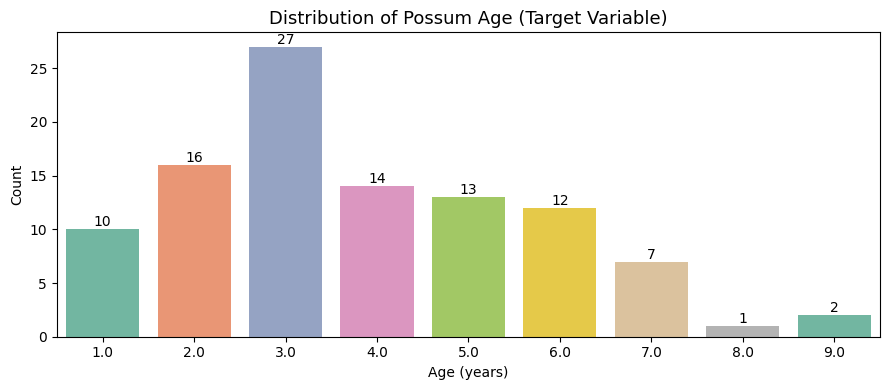

age
1.0    10
2.0    16
3.0    27
4.0    14
5.0    13
6.0    12
7.0     7
8.0     1
9.0     2
Name: count, dtype: int64


In [96]:
plt.figure(figsize=(9, 4))
ax = sns.countplot(data=df, x='age', palette='Set2', order=sorted(df['age'].dropna().unique()))
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title("Distribution of Possum Age (Target Variable)", fontsize=13)
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print(df['age'].value_counts().sort_index())

**Finding:** Age 3 is the most common (27 possums), while ages 8 and 9 are rare (1–2 possums each). The distribution is right-skewed — most possums in the sample are young (1–4 years). This means predictions for older possums may be less reliable due to limited training data.

### 4.7 Distribution of Numerical Features

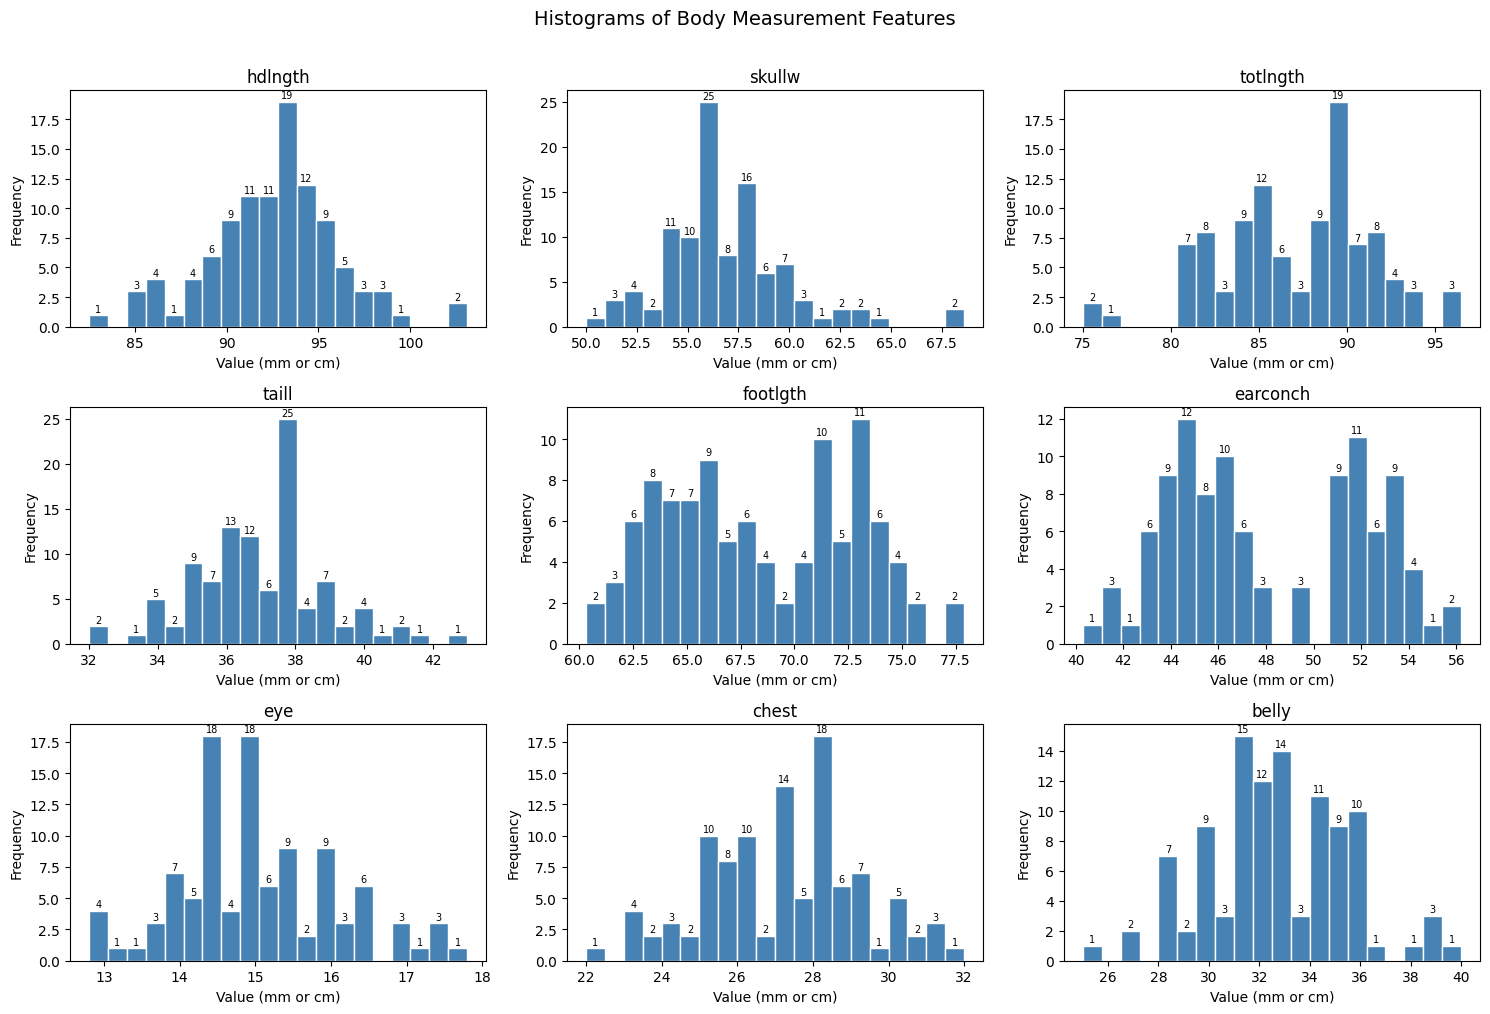

In [97]:
num_cols = ['hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    n, bins, patches = axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel("Value (mm or cm)")
    axes[i].set_ylabel("Frequency")


    for patch, count in zip(patches, n):
        if count > 0:
            axes[i].text(
                patch.get_x() + patch.get_width() / 2,
                patch.get_height() + 0.1,
                str(int(count)),
                ha='center', va='bottom', fontsize=7
            )

plt.suptitle("Histograms of Body Measurement Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Finding:** Most body measurements follow near-normal distributions. `earconch` appears slightly right-skewed. Overall the features are well-distributed and suitable for KNN.

### 4.8 Scatter Plots — Age vs Key Features

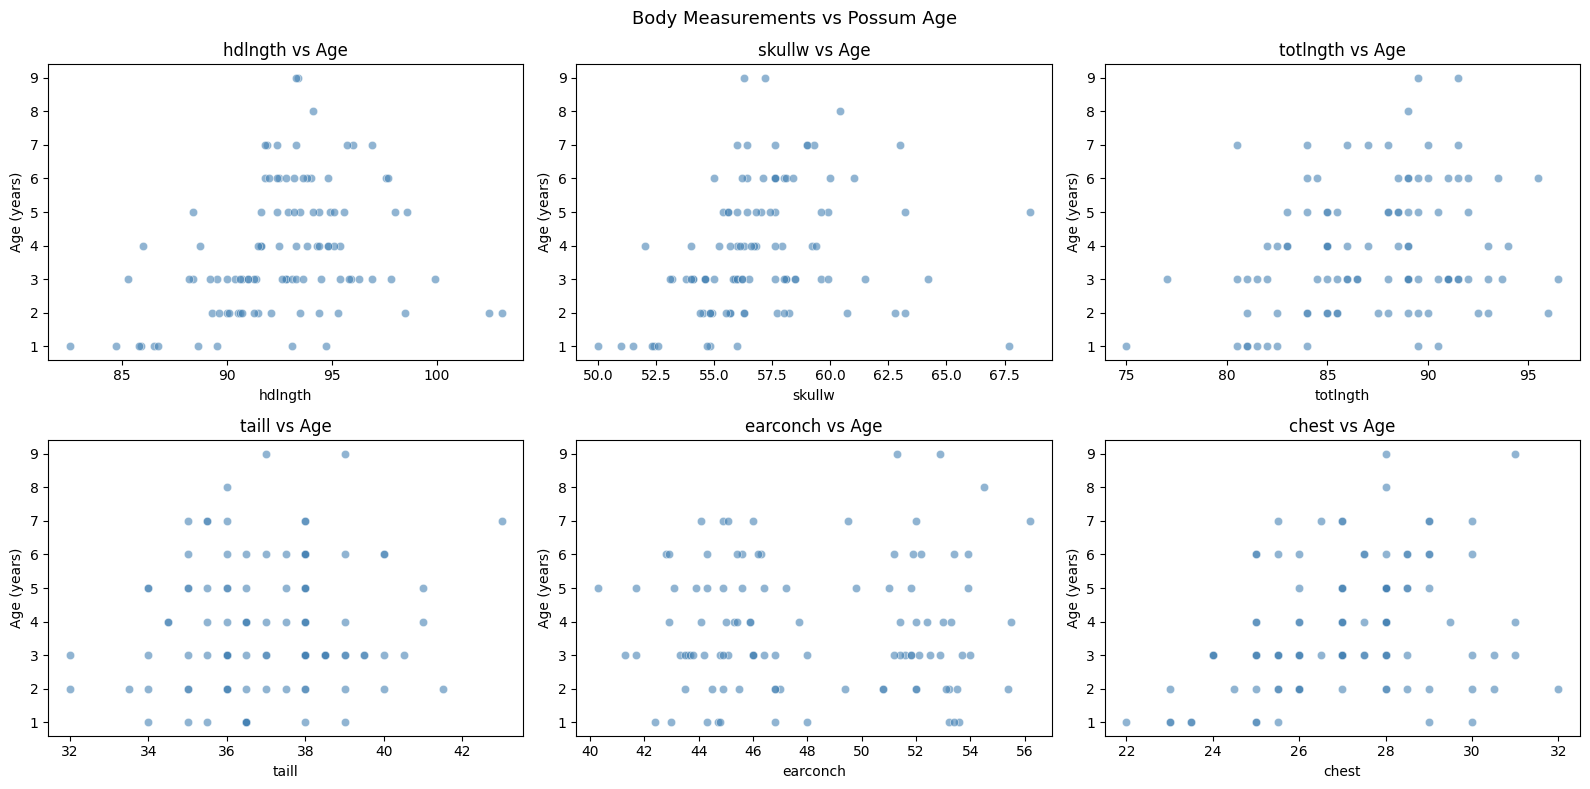

In [98]:
features_to_plot = ['hdlngth', 'skullw', 'totlngth', 'taill', 'earconch', 'chest']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    axes[i].scatter(df[feat], df['age'], alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Age (years)")
    axes[i].set_title(f'{feat} vs Age')

plt.suptitle("Body Measurements vs Possum Age", fontsize=13)
plt.tight_layout()
plt.show()

**Finding:** No single feature has a perfectly linear relationship with age, which is expected. `hdlngth` and `skullw` show a mild positive correlation with age. This confirms that a non-parametric method like KNN, which can capture non-linear patterns, is a good choice.

### 4.9 Boxplots — Age Group vs Body Measurements


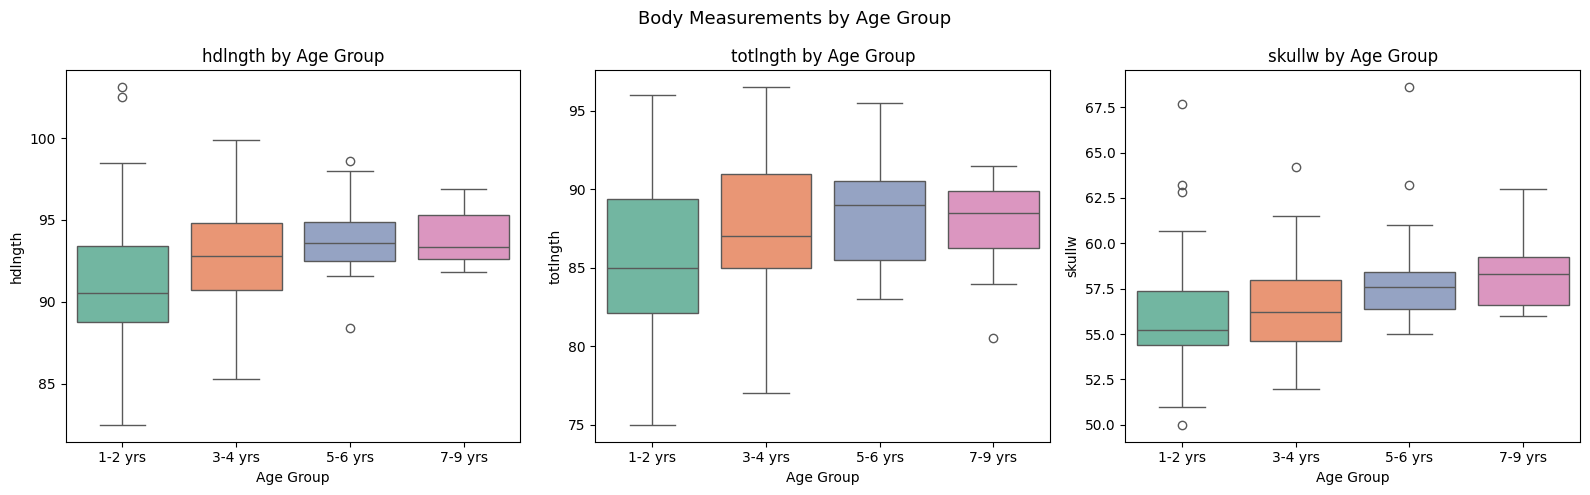

In [99]:
df_plot = df.dropna(subset=['age']).copy()
df_plot['age_group'] = pd.cut(df_plot['age'], bins=[0,2,4,6,9],
                               labels=['1-2 yrs', '3-4 yrs', '5-6 yrs', '7-9 yrs'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feat in enumerate(['hdlngth', 'totlngth', 'skullw']):
    sns.boxplot(data=df_plot, x='age_group', y=feat, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{feat} by Age Group')
    axes[i].set_xlabel("Age Group")

plt.suptitle("Body Measurements by Age Group", fontsize=13)
plt.tight_layout()
plt.show()


**Finding:** Older possums (7–9 years) tend to have larger head lengths and skull widths, confirming these are useful predictors for age.

### 4.10 Age by Population and Sex

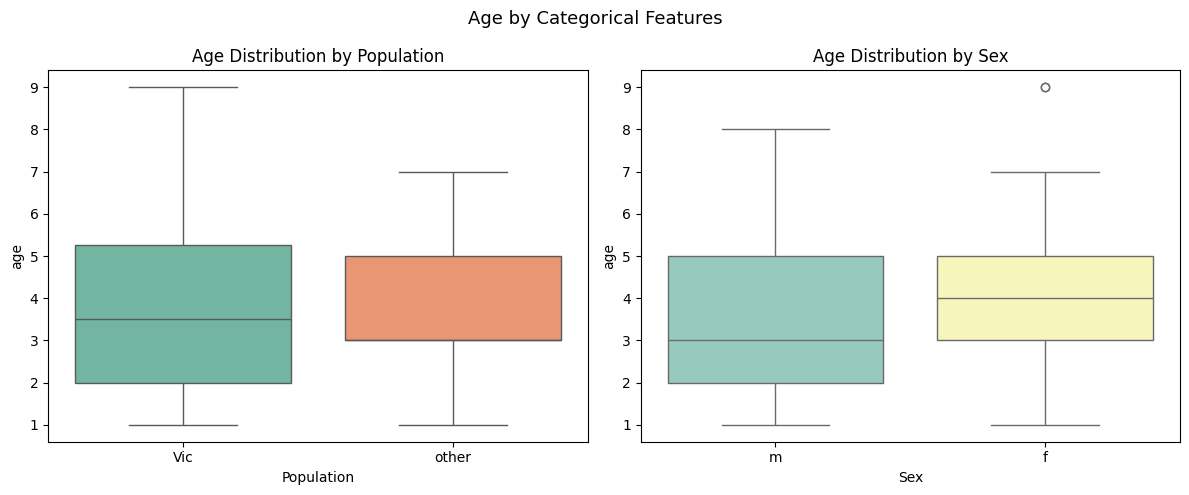

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='Pop', y='age', palette='Set2', ax=axes[0])
axes[0].set_title("Age Distribution by Population")
axes[0].set_xlabel("Population")

sns.boxplot(data=df, x='sex', y='age', palette='Set3', ax=axes[1])
axes[1].set_title("Age Distribution by Sex")
axes[1].set_xlabel("Sex")

plt.suptitle("Age by Categorical Features", fontsize=13)
plt.tight_layout()
plt.show()

**Finding:** Both populations (`Vic` and `other`) and both sexes have similar age distributions. Neither categorical feature appears to be a strong predictor of age on its own, but they may still contribute marginally when combined with body measurements.

### 4.11 Correlation Heatmap


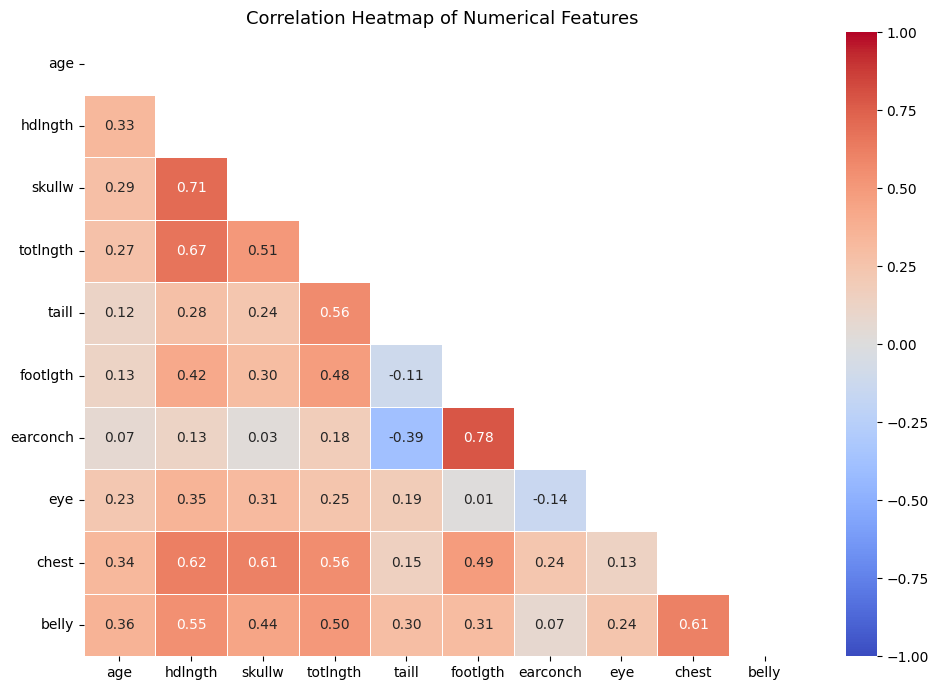

In [101]:
num_df = df[['age', 'hdlngth', 'skullw', 'totlngth', 'taill',
              'footlgth', 'earconch', 'eye', 'chest', 'belly']].dropna()

plt.figure(figsize=(10, 7))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

> **Finding:**
> - `hdlngth` (0.33), `skullw` (0.29), `totlngth` (0.27), `chest` (0.34),
>   and `belly` (0.36) show the strongest positive correlations with `age` —
>   older possums tend to be larger overall.
> - `taill` (0.12), `footlgth` (0.13)  and `earconch` (0.07) show very weak correlations with age,
>   meaning tail, footlgth and ear size are poor predictors of age.
> - Many body measurements are highly correlated with each other
>   (e.g., `hdlngth` & `skullw` = 0.71, `footlgth` & `earconch` = 0.78),
>   which is expected since body dimensions tend to scale together.
> - Notably, `tail` and `earconch` show a **negative correlation** (-0.39),
>   suggesting possums with larger tail tend to have smaller ear conchs.

## 5. Data Cleaning

The EDA revealed two issues to handle:

1. **Missing `age` values (2 rows):** Since `age` is our target variable, we cannot impute it — we must drop these rows.
2. **Missing `footlgth` value (1 row):** We fill this with the **median** of the column (robust to skew and outliers).

There are no duplicate rows to handle.


### 5.1 Drop rows where target variable (age) is missing

In [102]:
print(f"Rows before dropping missing age: {len(df)}")
df.dropna(subset=['age'], inplace=True)
print(f"Rows after dropping missing age : {len(df)}")
print()


Rows before dropping missing age: 104
Rows after dropping missing age : 102



### 5.2 Impute missing footlgth with median

it will be done inside the pipeline by the simple imputer

## 6. Feature Selection

### 6.1 Removing Irrelevant Columns

In [103]:
df.drop(columns=['case', 'site'], inplace=True, errors='ignore')
print("Columns after dropping case:", list(df.columns))

Columns after dropping case: ['Pop', 'sex', 'age', 'hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly']


The `case` column is just a unique identifier for each possum. It carries no biological information and should be removed — otherwise the model might learn spurious patterns from row numbers.



`site` is a geographic capture location identifier. Since Pop already encodes population-level geographic variation, and OneHotEncoding 7 site categories would introduce unnecessary dimensionality for a KNN model on 102 rows, site is dropped.

## 7. Data Preprocessing

KNN requires all input features to be **numerical**. Our dataset has two categorical text columns (`Pop` and `sex`). We need to encode them into numbers.

We also need to **scale** numerical features — KNN is entirely distance-based, and features with larger ranges will dominate the distance calculation without scaling.

Instead of manually encoding and scaling features, we let the **Pipeline** handle all preprocessing automatically and safely.

We define which columns are categorical and which are numerical — the Pipeline applies the correct transformer to each group:

- **Numerical columns** → `StandardScaler`
- **Categorical columns** → `OneHotencoder`

> **Why not encode manually?**  
> Doing it inside the Pipeline ensures transformations are fit **only on training data** during each cross-validation fold — preventing data leakage that manual preprocessing would introduce.

In [104]:
X = df.drop(columns=['age'])
y = df['age']

categorical_cols = ['Pop', 'sex']
numerical_cols   = [c for c in X.columns if c not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numerical columns  :", numerical_cols)
print()
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Categorical columns: ['Pop', 'sex']
Numerical columns  : ['hdlngth', 'skullw', 'totlngth', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly']

X shape: (102, 11)
y shape: (102,)


## 8. Train-Test Split

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set : {X_test.shape[0]} samples")

Training set: 81 samples
Testing set : 21 samples


We split the data into **80% training** and **20% testing** with a fixed random state for reproducibility.

## 9. Building The Model

### 9.1 Pipeline Structure

In [106]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('knn', KNeighborsRegressor())
])


```
Pipeline
├── preprocessor  (ColumnTransformer)
│   ├── num_pipeline → SimpleImputer(median) → StandardScaler
│   └── cat_pipeline → OneHotEncoder
└── knn  (KNeighborsRegressor)
```
**Key benefits:**
- Prevents **data leakage** — the scaler fits only on training folds during CV
- Cleaner, reproducible code
- `GridSearchCV` can tune all hyperparameters across both preprocessing and model steps together

---

### 9.2 We Tune the hyperparameters  Using Grid Search & Fit the Model

In [107]:
from scipy.sparse import random_array
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 19],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['hdlngth',
                                                                          'skullw',
                                                                          'totlngth',
                                                                          'taill',
                                                                          'footlgth',
                                                                          'earconch',
                                                                          'eye',
                                                                          'chest',
                                                                          'belly']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Pop',
                                                                          'sex'])])),
                                       ('knn', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19],
                         'knn__weights': ['uniform', 'distance']},
             scoring='r2')

| Parameter | Values | Meaning |
|---|---|---|
| `knn__n_neighbors` | 3, 5, 7, 9, 11, 13, 15, 17, 19 | Number of neighbors K |
| `knn__weights` | `uniform`, `distance` | Equal weight vs. closer neighbors weighted more |
| `knn__metric` | `euclidean`, `manhattan` | Distance formula used |

We trained the model and used grid search to tune the hyperparameters to get the best choices

### 9.3 Print the Best Parameters

In [108]:
print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

Best Params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}


I printed the best parameters chosen by the grid search.

### 9.4 Prediction

In [109]:
y_pred = best_model.predict(X_test)

making the model Predict

## 10. Model Evaluation

In [110]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 1.4941834943369787
MSE: 3.258711755531146
RMSE: 1.8051902269653317
R2 Score: 0.2871568034775618


**What do these metrics mean?**

- **MAE:** On average, our predicted age is off by MAE years — the most intuitive metric.
- **MSE:** Average squared error — penalizes large errors more heavily than MAE.
- **RMSE:** Square root of MSE — same unit as age (years), easier to interpret than MSE.
- **R² Score:** Proportion of variance in age explained by the model. R² = 1.0 is perfect; R² = 0.0 means the model is no better than always predicting the mean age.

## 11. Saving Model

In [111]:
with open("knn_possum_pipeline.pkl", "wb") as f:
    pickle.dump(best_model, f)

I Saved The Model

## 12. Conclusion

### Key Findings from EDA

- The dataset contains **102 possum records** (after dropping 2 rows with missing target age) across 13 features.
- Age 3 is the most common (27 possums); ages 8–9 are rare — predictions for older possums may be less reliable.
- `hdlngth`, `skullw`, `totlngth`, `chest`, and `belly` show the strongest positive correlations with age.
- Many body measurements are correlated with each other (body size scales together), which KNN handles naturally.

### Data Cleaning and Preprocessing (inside Pipeline)

- **2 rows with missing `age`** were dropped (target variable — cannot impute).
- **1 missing `footlgth`** is imputed with the column median inside the Pipeline using `SimpleImputer`.
- `case` was removed as a non-informative identifier.
- `One Hot Encoder` was applied to `Pop` and `sex` inside the Pipeline.
- **StandardScaler** was applied to all numerical features inside the Pipeline — critical for KNN since it is purely distance-based.

### Model Performance

| Metric | Value |
|---|---|
| MAE | *1.4942* |
| MSE | *3.2587* |
| RMSE | *1.8052* |
| R² Score | *0.2872* |

### Final Observations

- KNN with Pipeline provides a leak-free, reproducible baseline for this problem, though an R² of 0.29 reflects a modest result — expected given the small dataset (102 rows), the weak feature-target correlations (max 0.36), and the scarcity of older possum samples (ages 7–9) that limits the model's ability to generalize across the full age range.

- The right-skewed age distribution means the model sees fewer examples of old possums (7–9 years) and may predict those less accurately.
- Future improvements could include: trying different distance metrics (Manhattan, Minkowski), feature engineering (ratios of body measurements), or comparing against a Random Forest Regressor.
- The complete pipeline is saved as `knn_possum_pipeline.pkl` and ready for deployment.